# Рубежный контроль №1 — вариант 6
# Илюхин Илья Денисович ИУ5-66Б

- Вариант 6 → **Задача 1** и **датасет №6** (`Admission_Predict_Ver1.1.csv`).
- Требование задачи 1: провести корреляционный анализ и сделать выводы для последующего моделирования.


In [7]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')
url = 'https://raw.githubusercontent.com/hamzanasirr/Predicting-Graduate-Admissions-using-Machine-Learning-in-Python/master/Admission_Predict_Ver1.1.csv'
df = pd.read_csv(url)
df.columns = [c.strip() for c in df.columns]


## 1. Проверка и подготовка данных


In [8]:
print('Размер исходного датасета:', df.shape)
display(df.head())

missing_cols = df.columns[df.isna().any()].tolist()
print('Колонки с пропусками:', missing_cols if missing_cols else 'нет')

clean_df = df.dropna(axis=0).copy()
if 'Serial No.' in clean_df.columns:
    clean_df = clean_df.drop(columns=['Serial No.'])

print('Размер после dropna:', clean_df.shape)


Размер исходного датасета: (500, 9)


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Колонки с пропусками: нет
Размер после dropna: (500, 8)


## 2. Корреляционный анализ


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.827200,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL Score,0.827200,1.000000,0.649799,0.644410,0.541563,0.810574,0.467012,0.792228
University Rating,0.635376,0.649799,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644410,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541563,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810574,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.467012,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance of Admit,0.810351,0.792228,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


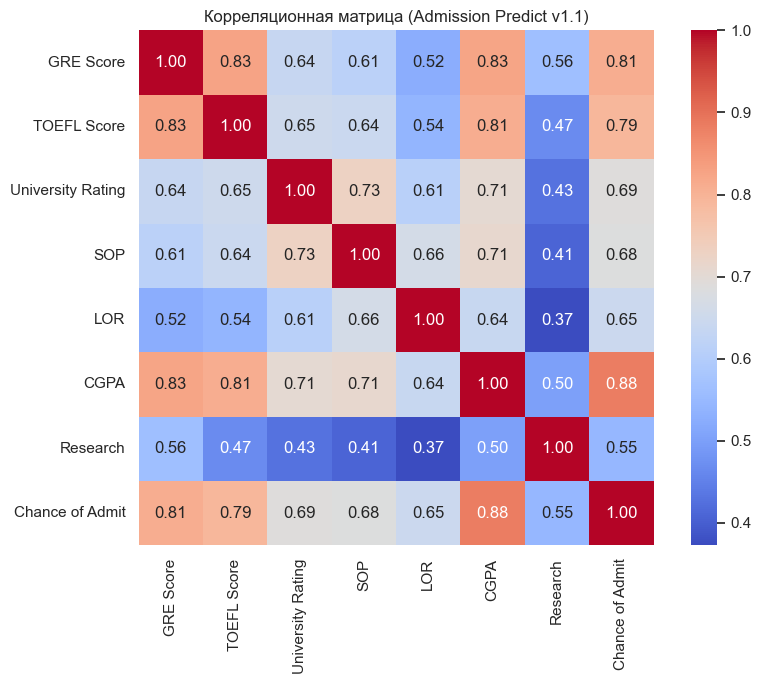

<Figure size 640x480 with 0 Axes>

In [9]:
corr = clean_df.corr(numeric_only=True)
display(corr)

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица (Admission Predict v1.1)')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'correlation_heatmap.png', dpi=170, bbox_inches='tight')


## 3. Анализ связей с целевым признаком


,abs_corr_with_target
CGPA,0.882413
GRE Score,0.810351
TOEFL Score,0.792228
University Rating,0.690132
SOP,0.684137
LOR,0.645365
Research,0.545871


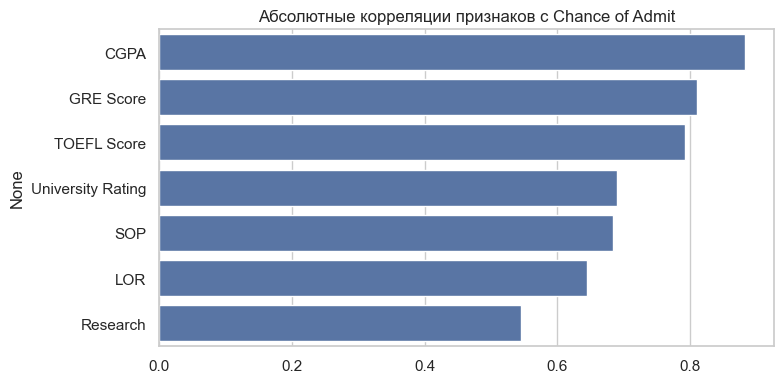

<Figure size 640x480 with 0 Axes>

In [10]:
target = 'Chance of Admit' if 'Chance of Admit' in corr.columns else 'Chance of Admit '
abs_corr = corr[target].drop(labels=[target]).abs().sort_values(ascending=False)
display(abs_corr.to_frame('abs_corr_with_target'))

plt.figure(figsize=(8,4))
sns.barplot(x=abs_corr.values, y=abs_corr.index)
plt.title('Абсолютные корреляции признаков с Chance of Admit')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'target_correlations.png', dpi=170, bbox_inches='tight')


## 4. Сохранение отчётных артефактов


In [ ]:
clean_df.to_csv(ART / 'Admission_Predict_Ver1.1_clean.csv', index=False)
corr.to_csv(ART / 'correlation_matrix.csv')

summary = {
    'dataset_shape_before': list(df.shape),
    'dataset_shape_after_dropna': list(clean_df.shape),
    'columns_with_missing': missing_cols,
    'target_column': target,
    'top_features_by_abs_corr_with_target': abs_corr.head(5).to_dict(),
}
import json
(ART / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

print('Сохранено в', ART)


Сохранено в /Users/macbook/Documents/ML/rk1/artifacts
